# **任务16 注意力机制 - (2) | Attention Mechanism (2)**

继上一个任务，这次来介绍另一种注意力机制。

## 1. **层记录器类**

只是一个可视化类，并不是深度学习必要的。

In [359]:
import torch
import numpy as np

class NestedLayerGetter:
    """按前向传播顺序记录中间层输出的工具类（支持嵌套Sequential结构）"""
    def __init__(self, model, device='cuda', record_on_train=False, layers_to_record=None):
        self.model = model
        self.device = device
        self.record_on_train = record_on_train  # 训练时是否记录
        self.layers_to_record = layers_to_record  # 指定需要记录的层，None表示所有层
        self.intermediate_outputs = []  # 根层级的输出列表
        self.hooks = []
        self.parent_map = {}  # 记录层与父层的关系
        self.layer_info = {}  # 临时存储层信息，用于构建嵌套结构

        # 首先构建模型的层级结构
        self._build_hierarchy(model)
        # 注册钩子
        self._register_hooks()

    def _build_hierarchy(self, model):
        """构建模型的层级结构，记录每个层的父级"""

        def traverse(parent, module, parent_name=''):
            for name, child in module.named_children():
                current_name = f"{parent_name}.{name}" if parent_name else name
                self.parent_map[current_name] = parent_name
                # 如果是容器类型，继续遍历
                if isinstance(child, (nn.Sequential, nn.ModuleList, nn.ModuleDict)):
                    traverse(current_name, child, current_name)

        traverse('', model)

    def _register_hooks(self):
        """注册钩子，按前向传播顺序记录（支持嵌套结构）"""
        def get_hook(name):
            def hook(module, input, output):
                # 训练模式下且不允许记录时直接返回
                if self.model.training and not self.record_on_train:
                    return

                # 如果指定了需要记录的层且当前层不在其中，则跳过
                if self.layers_to_record is not None and name not in self.layers_to_record:
                    return

                # 处理输入（转为CPU numpy以优化显存）
                processed_input = []
                for inp in input:
                    if isinstance(inp, torch.Tensor):
                        processed_inp = inp.detach().cpu().numpy()  # 切断计算图+转移CPU
                        processed_input.append(processed_inp)
                    else:
                        processed_input.append(inp)

                # 处理输出（转为CPU numpy以优化显存）
                if isinstance(output, torch.Tensor):
                    processed_output = output.detach().cpu().numpy()
                elif isinstance(output, tuple):
                    processed_output = []
                    for out in output:
                        if isinstance(out, torch.Tensor):
                            processed_out = out.detach().cpu().numpy()
                            processed_output.append(processed_out)
                        else:
                            processed_output.append(out)
                    processed_output = tuple(processed_output)
                else:
                    processed_output = output

                # 创建当前层的信息字典
                layer_info = {
                    'name': name.split('.')[-1],  # 只保留最后一级名称
                    'full_name': name,  # 保留完整名称
                    'input': processed_input,
                    'output': processed_output,
                    'module_type': module.__class__.__name__,
                    'children': []  # 用于存储子层
                }

                # 存储层信息
                self.layer_info[name] = layer_info

                # 清理临时变量，减少内存占用
                del processed_input, processed_output

            return hook

        # 为所有子模块注册钩子（按模型结构顺序）
        for name, module in self.model.named_modules():
            if name:  # 跳过根模块（模型本身）
                hook = get_hook(name)
                self.hooks.append(module.register_forward_hook(hook))

    def __call__(self, x):
        """执行前向传播并返回最终输出，每次调用前清空历史记录"""
        self.intermediate_outputs = []
        self.layer_info = {}
        output = self.model(x)

        # 构建嵌套结构
        self._build_nested_structure()
        return output

    def _build_nested_structure(self):
        """根据记录的层信息和父级关系构建嵌套结构"""
        # 首先找出所有顶层节点（没有父节点或父节点未被记录）
        top_level_nodes = []
        for name in self.layer_info:
            parent_name = self.parent_map.get(name, '')
            if parent_name not in self.layer_info:
                top_level_nodes.append(name)

        # 按名称排序，确保顺序正确
        top_level_nodes.sort()

        # 递归构建嵌套结构
        def build_children(parent_name):
            children = []
            # 找出所有以parent_name为前缀的子节点
            for name in self.layer_info:
                if self.parent_map.get(name, '') == parent_name:
                    # 递归构建子节点的子节点
                    self.layer_info[name]['children'] = build_children(name)
                    children.append(self.layer_info[name])
            # 按名称排序
            children.sort(key=lambda x: x['full_name'])
            return children

        # 构建顶层节点的子节点
        for name in top_level_nodes:
            self.layer_info[name]['children'] = build_children(name)
            self.intermediate_outputs.append(self.layer_info[name])

    def clear(self):
        """手动清空记录，释放内存"""
        self.intermediate_outputs = []
        self.layer_info = {}
        import gc
        gc.collect()

    def __del__(self):
        """删除钩子，避免内存泄漏"""
        for hook in self.hooks:
            hook.remove()
        self.clear()

## 2. 多头注意力机制（QKV）

这是深度学习中非常经典的注意力机制，torch框架中有封装好的层可以直接使用。

### 2.1 数据生成
以 **任务11** 为例大学名称命名实体识别。

In [360]:
import thulac

thu1 = thulac.thulac(seg_only=True)

max_len = 30
space_mark = '<S>'
NoName_mark = '/'
MidName_mark = '-'

name_list = ['杭电信工', '杭州电子科技大学信息工程学院', '杭州电子科技大学', '杭州电子科技大学（青山湖校区）', '电子科技大学', '北京大学','北大', '清华', '清华大学', '浙江中医药大学', '国防科技大学', '合肥工业大学', '杭州师范大学', '浙江工商大学', '浙江农林大学','安徽医科大学', '安徽农业大学', '合肥理工大学', '合工大', '杭电', '复旦大学', '复旦', '上海交通大学', '上交', '上海交大', '南京大学', '南大', '东南大学', '东大', '武汉大学', '武大', '华中科技大学', '华科', '四川大学', '川大', '电子科技大学（成都）', '成电', '西安交通大学', '西交', '西北工业大学', '西工大', '中山大学', '中大', '华南理工大学', '华工', '浙江大学', '浙大', '中国科学技术大学', '中科大', '南京航空航天大学', '南航', '湖南大学', '湖大', '中南大学', '中南', '暨南大学', '暨大', '西南交通大学', '西南交大', '华东师范大学', '华师大', '上海财经大学', '上财', '中央财经大学', '央财', '中国医科大学', '中国医大', '南京医科大学', '南医大', '华中师范大学', '华师', '华南师范大学', '华南师大']

sentence_list = [
    '我是Name的一名学生',
    '我目前就读于Name',
    'Name是我所在的学府',
    '我正在Name接受教育',
    'Name是我选择的大学',
    '我是Name的学子',
    '我在Name深造',
    'Name是我求学的地方',
    '我于Name就读',
    '我正在Name攻读学位',
    'Name是我梦想中的大学',
    '我很高兴能在Name学习',
    'Name是我学术旅程的起点',
    '我选择了Name作为我的大学',
    '在Name，我追求知识的真谛',
    'Name为我提供了广阔的学习平台',
    '我是Name的一份子',
    'Name见证了我的成长与学习',
    '我将在Name完成我的学业',
    'Name是我人生中的重要一站',
    '我在Name就读',
    'Name是我目前就读的高等学府',
    '我正在Name接受高等教育',
    'Name是我选择深造的大学',
    '我于Name开始学习之旅',
    '在Name，我开始了我的大学生活',
    'Name是我梦想中的学府，我现在正在那里学习',
    '我目前的学习地点是Name',
    '我正在Name攻读我的学位',
    'Name是我求学之路的下一站',
    '我很高兴能在Name这样的名校学习',
    '作为Name的学生，我感到非常自豪',
    '在Name的学习经历对我来说非常宝贵',
    '我正在Name努力提升自己的学识和能力',
    'Name拥有一支高水平的师资队伍',
    '师资力量是Name发展的坚实后盾',
    'Name积极与国内外高校开展合作交流',
]

X_dict = {}
for sentence in sentence_list:
    for name in name_list:
        sentence0 = sentence.replace('Name', name)
        result = [i[0] for i in thu1.cut(sentence0)]
        X_dict[tuple(result)] = name

print('样本数：', len(X_dict))

X_data = []
Y_data = []
test = False
for words, name in X_dict.items():
    sentence_list = []
    for word in words:
        if word in name:
            sentence_list.append(MidName_mark)
        else:
            sentence_list.append(NoName_mark)

    words = list(words)

    while len(words) < max_len:
        words.append(space_mark)
        sentence_list.append(NoName_mark)

    X_data.append(list(words))
    Y_data.append(sentence_list)

# print(X_data)
# print(Y_data)

# 构建词汇表，为每个词分配数字索引
all_words = []
for x in X_data:
    all_words.extend(x)
for y in Y_data:
    all_words.extend(y)
vocab = sorted(set(all_words))

word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}  # 方便后续将索引转换回词

# 将数据中的词转换为数字索引表示
X_data_idx = [[word_to_idx[word] for word in x] for x in X_data]
Y_data_idx = [[word_to_idx[word] for word in y] for y in Y_data]

train_x = torch.tensor(X_data_idx)
train_y = torch.tensor(Y_data_idx)

batch_size = 128
# 划分批次
def split_batch(data, batch_size):
    # 核心操作：沿第一个维度（dim=0）分割，保留后续所有维度
    split_tensors = torch.split(data, batch_size, dim=0)
    # 转为列表返回（torch.split返回tuple，列表更易操作）
    return list(split_tensors)

train_x_batch = split_batch(train_x, batch_size)
train_y_batch = split_batch(train_y, batch_size)

print('输入数据形状:', train_x.shape)
print('输入批次数量:', len(train_x_batch), '\t批次形状:', train_x_batch[0].shape)
print('标签数据形状:', train_y.shape)
print('输入批次数量:', len(train_y_batch), '\t批次形状:', train_y_batch[0].shape)

Model loaded succeed
样本数： 2701
输入数据形状: torch.Size([2701, 30])
输入批次数量: 22 	批次形状: torch.Size([128, 30])
标签数据形状: torch.Size([2701, 30])
输入批次数量: 22 	批次形状: torch.Size([128, 30])


### 2.2 定义注意力模块

注意力的关键是 `nn.MultiheadAttention(embed_dim=output_dim, num_heads=num_heads)` ，其中 `embed_dim` 必须能被 `num_heads` 整除

In [361]:
import torch.nn as nn

class AttnQKV(nn.Module):
    def __init__(self, input_dim, num_heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):
        y, _ = self.attn(x, x, x)
        return y

#### 2.2.1 定义模型

In [362]:
class MainModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_tags, num_heads=8):
        super(MainModel, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.attn = AttnQKV(embedding_dim, num_heads=num_heads)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_size, num_tags)

    def forward(self, x):
        x = self.embedding(x)
        attn_x = self.attn(x)
        x *= attn_x
        out, _ = self.rnn(x)

        out = self.fc(out)
        return out

#### 2.2.2 模型训练

将模型与层记录器绑定，并指定其记录 `surface_senet` 层的结果。

In [363]:
vocab_size = len(vocab)
embedding_dim = 32
hidden_size = 128
num_layers = 2
num_tags = vocab_size  # 根据标签种类确定类别数量
num_heads = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MainModel(vocab_size, embedding_dim, hidden_size, num_layers, num_tags, num_heads=num_heads).to(device)

recorder = NestedLayerGetter(
        model,
        record_on_train=False,  # 训练时不记录
        layers_to_record=['attn']
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### 2.2.3 **迭代训练**

In [364]:
num_epochs = 24
# 训练模型
for epoch in range(num_epochs):
    recorder.model.train()
    total_loss = 0
    for i in range(len(train_x_batch)):
        batch_x = train_x_batch[i].to(device)
        batch_y = train_y_batch[i].to(device)
        optimizer.zero_grad()
        outputs = recorder(batch_x)
        loss = criterion(outputs.view(-1, num_tags), batch_y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 4 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(train_x_batch)}')

Epoch 4/24, Loss: 0.2638268091461875
Epoch 8/24, Loss: 0.15188427371057597
Epoch 12/24, Loss: 0.02410470668903806
Epoch 16/24, Loss: 0.011598764886994932
Epoch 20/24, Loss: 0.006749268372500824
Epoch 24/24, Loss: 0.005661515757145191


#### 2.2.4 **测试模型**

使用 `model.eval()` 将模型改为测试模式，避免自动的梯度计算增加额外的计算量。

>>> 测试语句： 我正在上财接受教育
前向传播中共记录 1 个顶层步骤：


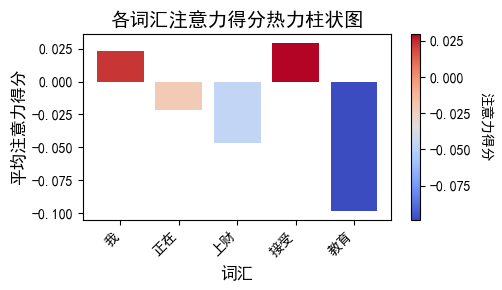

命名实体识别结果： 我正在上财接受教育 

>>> 测试语句： 在暨大，我开始了我的大学生活
前向传播中共记录 1 个顶层步骤：


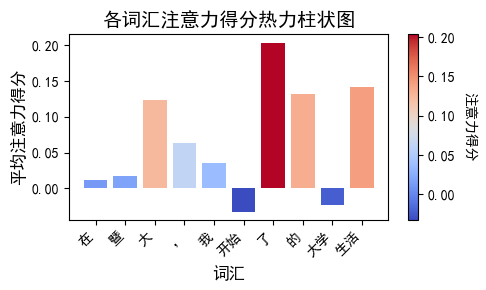

命名实体识别结果： 在暨大，我开始了我的大学生活 

>>> 测试语句： 我正在浙江大学努力提升自己的学识和能力
前向传播中共记录 1 个顶层步骤：


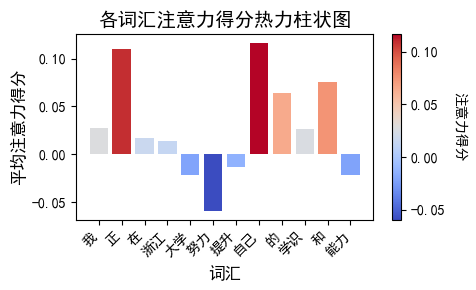

命名实体识别结果： 我正在浙江大学努力提升自己的学识和能力 

>>> 测试语句： 我于南航就读
前向传播中共记录 1 个顶层步骤：


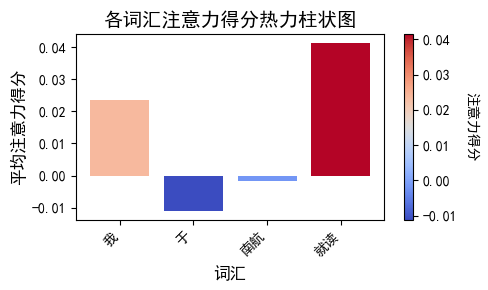

命名实体识别结果： 我于南航就读 

>>> 测试语句： 国防科技大学是我求学的地方
前向传播中共记录 1 个顶层步骤：


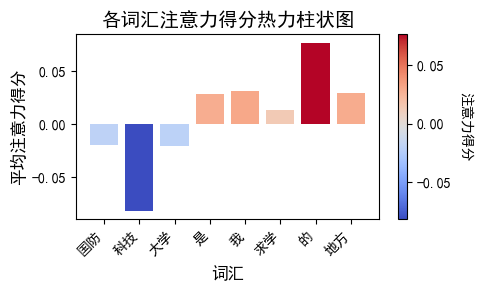

命名实体识别结果： 国防科技大学是我求学的地方 



In [365]:
import random
import matplotlib.pyplot as plt

# 简单的预测函数（这里只是示例，实际应用中可进一步完善）
def predict(model, sentence):
    result = [i[0] for i in thu1.cut(sentence)]
    words_idx = [word_to_idx.get(word, word_to_idx[space_mark]) if word in word_to_idx else word_to_idx.get(space_mark, word_to_idx) for word in result]
    while len(words_idx) < max_len:
        words_idx.append(word_to_idx[space_mark])
    input_tensor = torch.tensor([words_idx])
    words_idx = input_tensor.long().to(device)  # 转换为合适的张量形式
    with torch.no_grad():
        output = model(words_idx)
        predicted_tags = torch.argmax(output, dim=2)[0].tolist()
        predicted_tags = [idx_to_word[tag] for tag in predicted_tags]
    return result, predicted_tags

# 简单的测试示例（重新加载模型后进行预测）
recorder.model.eval()
# 示例预测
for x in random.choices(list(X_dict.keys()), k=5):
    # 我在杭州电子科技大学学习
    test_sentence = ''.join(x)
    print('>>> 测试语句：', test_sentence)
    words, predicted_result = predict(recorder, test_sentence)

    recoder_content = recorder.intermediate_outputs
    print(f"前向传播中共记录 {len(recoder_content)} 个顶层步骤：")
    atte_output_tensor = recoder_content[0]['output']
    attn_matrix = torch.tensor(atte_output_tensor).squeeze().numpy()[:len(words), :]

    attn_scores = np.mean(attn_matrix, axis=1)
    # 绘图配置
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 3))
    # 颜色映射
    norm = plt.Normalize(attn_scores.min(), attn_scores.max())
    cmap = plt.cm.coolwarm
    colors = cmap(norm(attn_scores))
    # 绘制热力柱状图
    bars = ax.bar(words, attn_scores, color=colors)
    # 添加颜色条
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('注意力得分', rotation=270, labelpad=15)
    # 坐标轴与标题
    ax.set_xlabel('词汇', fontsize=12)
    ax.set_ylabel('平均注意力得分', fontsize=12)
    ax.set_title('各词汇注意力得分热力柱状图', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    sentence = ''
    for i in range(len(predicted_result)):
        mark = predicted_result[i]
        if mark == '-':
            sentence += f'\033[91m{words[i]}\033[0m'
        else:
            try:
                sentence += words[i]
            except: break

    print('命名实体识别结果：', sentence, '\n')

由于文本结构存在一个特征向量维度，这里我使用了 `np.mean(attn_matrix, axis=1)` 方法对该维度进行了平均池化，忽视了部分维度特征，但总体能看出，语言模型似乎认为主语动词和一些助词更重要，学校的具体名称反而不太重要。

## 3. **总结**

注意力机制是一种自动帮助模型筛选关键特征的结构，有助于降低模型在后续特征提取的难度，同时要避免过拟合。可以引入dropout层用以减缓，其实现机制不做过多赘述了，实例化方法为 `nn.Dropout()`。